# Testing sampling of MF35 for U235

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sandy

In [2]:
endf6 = sandy.get_endf6_file("jeff_33", "xs", 922350)
endf6.to_file("U235.jeff33")

In [3]:
sandy.sampling.run("U235.jeff33 --mf 35 --samples 2 --seed35 5 --debug --loglevel error".split())

 - Parsing input file options...
	U235.jeff33 --mf 35 --samples 2 --seed35 5 --debug --loglevel error


Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing xs sample 0...
Processing x

In [4]:
smp = sandy.Samples.from_excel("PERT_92235_MF35.xlsx")

In [5]:
# Extract energy distributions from original and perturbed files
edistr = sandy.Edistr.from_endf6(endf6)
edistr0 = sandy.Edistr.from_endf6(sandy.Endf6.from_file("92235_0.endf6"))
edistr1 = sandy.Edistr.from_endf6(sandy.Endf6.from_file("92235_1.endf6"))

# Calculate ratios, this should be compared to the random samples
edistr.data["RATIO0"] = edistr0.data.VALUE / edistr.data.VALUE
edistr.data["RATIO1"] = edistr1.data.VALUE / edistr.data.VALUE

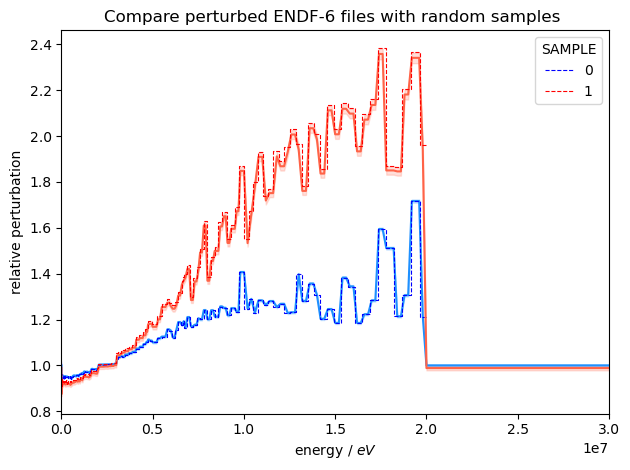

In [6]:
fig, ax = plt.subplots()

sns.lineplot(data=edistr.data, x="EOUT", y="RATIO0", errorbar="sd", ax=ax, color="dodgerblue")
smp.get_eright()[0].reset_index().plot(x="ERIGHT", y=0, drawstyle="steps-pre", ax=ax, color="blue", ls="--", lw=.8)

sns.lineplot(data=edistr.data, x="EOUT", y="RATIO1", errorbar="sd", ax=ax, color="tomato")
smp.get_eright()[1].reset_index().plot(x="ERIGHT", y=1, drawstyle="steps-pre", ax=ax, color="red", ls="--", lw=.8)

ax.set(xlim=[0,3e7], ylabel='relative perturbation', xlabel='energy / $eV$', title="Compare perturbed ENDF-6 files with random samples ")
ax.legend(title="SAMPLE")
fig.tight_layout()